# Approach A: engineered features + gradient boosting (leakage-free)
Data reading -> signals -> features -> group CV -> ablation -> held-out test -> save/predict.
Run top-to-bottom. Works as a plain script or as notebook cells (`# %%` markers).

In [1]:
# 0. Imports & config
import os
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt
import seaborn as sns
from scipy import stats
from scipy.spatial.transform import Rotation as R
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("lightgbm not installed (pip install lightgbm) -> running ExtraTrees only")

warnings.filterwarnings("ignore")
sns.set_context("notebook")

DATA_DIR = "robot_data"      # folder with X_train.npy, groups.csv (and optionally X_test.npy)
OUT_DIR = "outputs_approach_a"
SEED = 42
TEST_FRAC = 0.20             # fraction of *sessions* held out as the final test set
CV_SPLITS = 5                # group folds on the development part
CV_REPEATS = 3               # repeat CV with different group shuffles (36 sessions -> noisy)
RUN_FLAT_BASELINE = True     # compare against your old "flatten + RF" idea under the same CV
RUN_ABLATION = True

os.makedirs(OUT_DIR, exist_ok=True)
rng = np.random.default_rng(SEED)

lightgbm not installed (pip install lightgbm) -> running ExtraTrees only


In [2]:
# 1. Read data + sanity checks
X = np.load(f"{DATA_DIR}/X_train.npy")                       # (N, 10, 128)
meta = pd.read_csv(f"{DATA_DIR}/groups.csv")
id_col = meta.columns[0]                                      # '# Id'
meta = meta.sort_values(id_col).reset_index(drop=True)

assert X.ndim == 3 and X.shape[1:] == (10, 128), f"unexpected shape {X.shape}"
assert len(meta) == len(X), "X_train.npy and groups.csv are not the same length"
assert np.isfinite(X).all(), "NaN/Inf in X"
assert (meta.groupby("Group Id")["Surface"].nunique() == 1).all(), "a session has >1 surface"

le = LabelEncoder()
y = le.fit_transform(meta["Surface"])
groups = meta["Group Id"].values
CLASSES = list(le.classes_)
N_CLASSES = len(CLASSES)

print(f"X: {X.shape} | sessions: {len(np.unique(groups))} | classes: {N_CLASSES}")
print(meta["Surface"].value_counts().to_string())
print("\nsessions per class:")
print(meta.groupby("Surface")["Group Id"].nunique().sort_values().to_string())

X: (1703, 10, 128) | sessions: 36 | classes: 9
Surface
soft_pvc                  390
carpet                    297
hard_tiles                291
hard_tiles_large_space    191
fine_concrete             187
soft_tiles                117
concrete                  107
tiled                     102
wood                       21

sessions per class:
Surface
wood                      1
concrete                  2
tiled                     2
soft_tiles                3
fine_concrete             4
hard_tiles_large_space    5
hard_tiles                6
carpet                    6
soft_pvc                  7


In [3]:
# 2. Physically meaningful signals
SIGNAL_NAMES = ["gyro_x", "gyro_y", "gyro_z", "gyro_mag",
                "acc_x", "acc_y", "acc_z", "acc_mag",
                "tilt_x", "tilt_y", "tilt_z"]


def build_signals(X):
    """(N,10,T) -> (N,11,T), every signal zero-mean per window.

    * Gravity direction in the sensor frame replaces raw quaternion/Euler angles:
      it is heading-free (cannot fingerprint a session) and has no angle wraparound.
    * Per-window mean removal strips gravity from accel and the turning rate from gyro,
      leaving the vibration dynamics, which is what depends on the floor.
    """
    N, _, T = X.shape
    q = X[:, 0:4, :].transpose(0, 2, 1).reshape(-1, 4)              # x, y, z, w
    q = q / np.linalg.norm(q, axis=1, keepdims=True)
    g = R.from_quat(q).inv().apply(np.array([0.0, 0.0, 1.0]))       # world-up in sensor frame
    g = g.reshape(N, T, 3).transpose(0, 2, 1)

    def demean(a):
        return a - a.mean(axis=2, keepdims=True)

    gyro, acc, tilt = demean(X[:, 4:7, :]), demean(X[:, 7:10, :]), demean(g)
    gyro_mag = np.linalg.norm(gyro, axis=1, keepdims=True)
    acc_mag = np.linalg.norm(acc, axis=1, keepdims=True)
    return np.concatenate([gyro, gyro_mag, acc, acc_mag, tilt], axis=1), g


S_all, g_all = build_signals(X)
print("signals:", S_all.shape)
print("gravity-in-body mean per axis (one axis should be close to +/-1):",
      g_all.mean((0, 2)).round(3))

signals: (1703, 11, 128)
gravity-in-body mean per axis (one axis should be close to +/-1): [ 0.015  0.296 -0.955]


In [4]:
# 3. Feature extraction (time + frequency + wavelet + cross-channel)
def time_feats(S):
    d = np.diff(S, axis=-1)
    std = S.std(-1)

    def ac(lag):
        return (S[..., :-lag] * S[..., lag:]).mean(-1) / (S.var(-1) + 1e-12)

    return {
        "std": std,
        "mad": np.median(np.abs(S - np.median(S, -1, keepdims=True)), -1),
        "iqr": stats.iqr(S, axis=-1),
        "skew": stats.skew(S, axis=-1),
        "kurt": stats.kurtosis(S, axis=-1),
        "ptp": np.ptp(S, axis=-1),
        "crest": np.abs(S).max(-1) / (std + 1e-12),
        "mad_diff": np.abs(d).mean(-1),
        "std_diff": d.std(-1),
        "zcr": (np.diff(np.sign(S), axis=-1) != 0).mean(-1),
        "ac1": ac(1), "ac2": ac(2), "ac4": ac(4), "ac8": ac(8),
    }


def spectral_feats(S, edges=(1, 2, 3, 5, 9, 17, 33, 65)):
    """Bin-based frequency features (no dependence on knowing the exact sampling rate)."""
    w = np.hanning(S.shape[-1])
    P = np.abs(np.fft.rfft(S * w, axis=-1)) ** 2
    P = P[..., 1:]                                                  # drop DC -> bins 1..T/2
    tot = P.sum(-1) + 1e-12
    p = P / tot[..., None]
    k = np.arange(1, P.shape[-1] + 1)
    out = {f"bp{b}": P[..., lo - 1:hi - 1].sum(-1) / tot
           for b, (lo, hi) in enumerate(zip(edges[:-1], edges[1:]))}
    out["centroid"] = (p * k).sum(-1)
    out["entropy"] = -(p * np.log(p + 1e-12)).sum(-1)
    out["flatness"] = np.exp(np.log(P + 1e-12).mean(-1)) / (P.mean(-1) + 1e-12)
    out["dom_bin"] = P.argmax(-1) + 1
    out["log_energy"] = np.log(tot)
    return out


def wavelet_feats(S, wavelet="db4", level=4):
    coeffs = pywt.wavedec(S, wavelet, level=level, axis=-1)
    e = np.stack([(c ** 2).sum(-1) for c in coeffs], axis=-1)
    rel = e / (e.sum(-1, keepdims=True) + 1e-12)
    out = {f"wv{i}": rel[..., i] for i in range(rel.shape[-1])}
    out["wv_entropy"] = -(rel * np.log(rel + 1e-12)).sum(-1)
    return out


CROSS_PAIRS = [("acc_x", "acc_y"), ("acc_x", "acc_z"), ("acc_y", "acc_z"),
               ("gyro_x", "gyro_y"), ("gyro_x", "gyro_z"), ("gyro_y", "gyro_z"),
               ("acc_z", "gyro_x"), ("acc_z", "gyro_y"), ("tilt_x", "tilt_y")]


def extract_features(S, names=SIGNAL_NAMES):
    cols = {}
    for tag, fdict in (("t", time_feats(S)), ("s", spectral_feats(S)), ("w", wavelet_feats(S))):
        for fname, arr in fdict.items():                            # arr: (N, n_signals)
            for j, sname in enumerate(names):
                cols[f"{sname}__{tag}_{fname}"] = arr[:, j]
    idx = {n: i for i, n in enumerate(names)}
    for a, b in CROSS_PAIRS:
        sa, sb = S[:, idx[a]], S[:, idx[b]]
        cols[f"corr__{a}__{b}"] = (sa * sb).mean(-1) / (sa.std(-1) * sb.std(-1) + 1e-12)
    F = pd.DataFrame(cols).replace([np.inf, -np.inf], np.nan)
    return F


t0 = time.time()
F_all = extract_features(S_all)
n_bad = int(F_all.isna().sum().sum())
F_all = F_all.fillna(0.0)
const_cols = F_all.columns[F_all.std() < 1e-12].tolist()
F_all = F_all.drop(columns=const_cols)
FEATURE_COLS = F_all.columns.tolist()
print(f"features: {F_all.shape} | NaN/Inf replaced: {n_bad} | constant dropped: {len(const_cols)} "
      f"| {time.time() - t0:.1f}s")


def featurize(X_new):
    """Raw (N,10,128) -> feature matrix with exactly the training columns."""
    S, _ = build_signals(X_new)
    F = extract_features(S).fillna(0.0)
    return F.reindex(columns=FEATURE_COLS, fill_value=0.0)

features: (1703, 359) | NaN/Inf replaced: 0 | constant dropped: 2 | 1.6s


In [5]:
# 4. Group-disjoint final test split (sessions never shared with development data)
def make_group_holdout(y, groups, test_frac=0.2, n_tries=300, seed=0):
    """Pick a session-level split whose test classes all also exist in the dev part,
    preferring tests that cover as many classes as possible."""
    n_splits = int(round(1 / test_frac))
    best = None
    for s in range(n_tries):
        cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed + s)
        dev, test = next(iter(cv.split(np.zeros(len(y)), y, groups)))
        if not set(y[test]).issubset(set(y[dev])):
            continue
        score = (len(set(y[test])), -abs(len(test) / len(y) - test_frac))
        if best is None or score > best[0]:
            best = (score, dev, test)
    return best[1], best[2]


dev_idx, test_idx = make_group_holdout(y, groups, TEST_FRAC, seed=SEED)
assert set(groups[dev_idx]).isdisjoint(groups[test_idx])

print(f"dev: {len(dev_idx)} windows / {len(np.unique(groups[dev_idx]))} sessions | "
      f"test: {len(test_idx)} windows / {len(np.unique(groups[test_idx]))} sessions")
print(pd.DataFrame({"dev": pd.Series(meta['Surface'].values[dev_idx]).value_counts(),
                    "test": pd.Series(meta['Surface'].values[test_idx]).value_counts()}
                   ).fillna(0).astype(int).to_string())

F_dev, y_dev, g_dev = F_all.iloc[dev_idx].reset_index(drop=True), y[dev_idx], groups[dev_idx]
F_te, y_te, g_te = F_all.iloc[test_idx].reset_index(drop=True), y[test_idx], groups[test_idx]

dev: 1367 windows / 28 sessions | test: 336 windows / 8 sessions
                        dev  test
carpet                  240    57
concrete                 51    56
fine_concrete           131    56
hard_tiles              234    57
hard_tiles_large_space  186     5
soft_pvc                333    57
soft_tiles              114     3
tiled                    57    45
wood                     21     0


In [6]:
# 5. Models + helpers
def expand_proba(proba, classes, n_classes):
    """A training fold can miss a class (e.g. one that has a single session)."""
    out = np.zeros((proba.shape[0], n_classes))
    out[:, classes] = proba
    return out


def get_model_makers(seed=SEED):
    makers = {
        "ExtraTrees": lambda: ExtraTreesClassifier(
            n_estimators=600, max_features="sqrt", min_samples_leaf=2,
            class_weight="balanced_subsample", n_jobs=-1, random_state=seed),
    }
    if HAS_LGB:
        makers["LightGBM"] = lambda: lgb.LGBMClassifier(
            n_estimators=400, learning_rate=0.03, num_leaves=15, max_depth=5,
            min_child_samples=15, subsample=0.7, subsample_freq=1, colsample_bytree=0.5,
            reg_lambda=5.0, class_weight="balanced", random_state=seed, verbose=-1)
    return makers


def cv_oof(F, y, groups, makers, n_splits=CV_SPLITS, n_repeats=CV_REPEATS, seed=SEED):
    """Repeated StratifiedGroupKFold. Returns {model: [oof_proba per repeat]} (+ 'Blend')."""
    Fv = np.asarray(F, dtype=np.float32)
    res = {name: [] for name in makers}
    for rep in range(n_repeats):
        cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed + rep)
        oofs = {name: np.zeros((len(y), N_CLASSES)) for name in makers}
        for tr, va in cv.split(Fv, y, groups):
            assert set(groups[tr]).isdisjoint(groups[va]), "group leakage!"
            for name, mk in makers.items():
                m = mk().fit(Fv[tr], y[tr])
                oofs[name][va] = expand_proba(m.predict_proba(Fv[va]), m.classes_, N_CLASSES)
        for name in makers:
            res[name].append(oofs[name])
    if len(makers) > 1:
        res["Blend"] = [np.mean([res[n][r] for n in makers], axis=0) for r in range(n_repeats)]
    return res


def summarize(res, y):
    rows = []
    for name, oofs in res.items():
        acc = [accuracy_score(y, o.argmax(1)) for o in oofs]
        bal = [balanced_accuracy_score(y, o.argmax(1)) for o in oofs]
        f1 = [f1_score(y, o.argmax(1), average="macro") for o in oofs]
        rows.append({"model": name,
                     "acc": f"{np.mean(acc):.3f} ± {np.std(acc):.3f}",
                     "balanced_acc": f"{np.mean(bal):.3f} ± {np.std(bal):.3f}",
                     "macro_F1": f"{np.mean(f1):.3f} ± {np.std(f1):.3f}"})
    return pd.DataFrame(rows).set_index("model")


def plot_cm(y_true, y_pred, title):
    cm = np.nan_to_num(confusion_matrix(y_true, y_pred, labels=range(N_CLASSES), normalize="true"))
    plt.figure(figsize=(8.5, 7))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [7]:
# 6. Reference: the old "flatten + forest" idea under the SAME group CV
if RUN_FLAT_BASELINE:
    X_flat_dev = X[dev_idx].reshape(len(dev_idx), -1)
    flat_makers = {"Flatten+ExtraTrees": lambda: ExtraTreesClassifier(
        n_estimators=300, n_jobs=-1, class_weight="balanced_subsample", random_state=SEED)}
    res_flat = cv_oof(X_flat_dev, y_dev, g_dev, flat_makers, n_repeats=1)
    print("Flattened baseline (group CV on dev):")
    print(summarize(res_flat, y_dev).to_string())
    print("Majority-class rate:", round(np.bincount(y_dev).max() / len(y_dev), 3))

Flattened baseline (group CV on dev):
                              acc   balanced_acc       macro_F1
model                                                          
Flatten+ExtraTrees  0.426 ± 0.000  0.279 ± 0.000  0.266 ± 0.000
Majority-class rate: 0.244


Group CV on dev (5 folds x 3 repeats) - 24s
                      acc   balanced_acc       macro_F1
model                                                  
ExtraTrees  0.561 ± 0.002  0.373 ± 0.001  0.360 ± 0.001

Per-class report (ExtraTrees, repeat 0, out-of-fold):
                        precision    recall  f1-score   support

                carpet       0.70      0.88      0.78       240
              concrete       0.00      0.00      0.00        51
         fine_concrete       0.76      0.62      0.68       131
            hard_tiles       0.57      0.62      0.59       234
hard_tiles_large_space       0.48      0.44      0.46       186
              soft_pvc       0.55      0.72      0.63       333
            soft_tiles       0.17      0.10      0.12       114
                 tiled       0.00      0.00      0.00        57
                  wood       0.00      0.00      0.00        21

              accuracy                           0.56      1367
             macro avg     

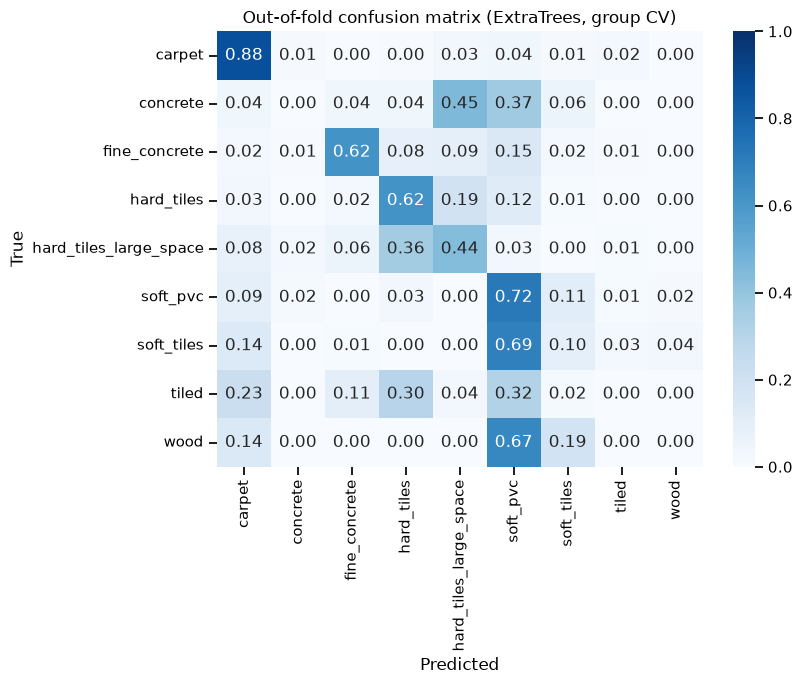

In [8]:
# 7. Main validation: repeated StratifiedGroupKFold on the development sessions
makers = get_model_makers()
t0 = time.time()
res = cv_oof(F_dev, y_dev, g_dev, makers)
print(f"Group CV on dev ({CV_SPLITS} folds x {CV_REPEATS} repeats) - {time.time() - t0:.0f}s")
print(summarize(res, y_dev).to_string())

best_name = "Blend" if "Blend" in res else "ExtraTrees"
oof0 = res[best_name][0]
print(f"\nPer-class report ({best_name}, repeat 0, out-of-fold):")
print(classification_report(y_dev, oof0.argmax(1), labels=range(N_CLASSES),
                            target_names=CLASSES, zero_division=0))
plot_cm(y_dev, oof0.argmax(1), f"Out-of-fold confusion matrix ({best_name}, group CV)")

In [9]:
# 8. Which feature families / signals carry the information? (fast ExtraTrees ablation)
if RUN_ABLATION:
    fam = {
        "time": [c for c in FEATURE_COLS if "__t_" in c],
        "spectral": [c for c in FEATURE_COLS if "__s_" in c],
        "wavelet": [c for c in FEATURE_COLS if "__w_" in c],
        "cross-corr": [c for c in FEATURE_COLS if c.startswith("corr__")],
    }
    combos = {
        "time": fam["time"],
        "spectral": fam["spectral"],
        "wavelet": fam["wavelet"],
        "time+spectral": fam["time"] + fam["spectral"],
        "time+spectral+wavelet": fam["time"] + fam["spectral"] + fam["wavelet"],
        "all": FEATURE_COLS,
    }
    et_only = {"ExtraTrees": get_model_makers()["ExtraTrees"]}
    rows = []
    for name, cols in combos.items():
        r = cv_oof(F_dev[cols], y_dev, g_dev, et_only, n_repeats=2)["ExtraTrees"]
        rows.append({"features": name, "n": len(cols),
                     "acc": np.mean([accuracy_score(y_dev, o.argmax(1)) for o in r]),
                     "macro_F1": np.mean([f1_score(y_dev, o.argmax(1), average="macro") for o in r])})
    print(pd.DataFrame(rows).round(3).to_string(index=False))

             features   n   acc  macro_F1
                 time 152 0.555     0.364
             spectral 132 0.520     0.325
              wavelet  66 0.480     0.296
        time+spectral 284 0.558     0.360
time+spectral+wavelet 350 0.564     0.364
                  all 359 0.562     0.361


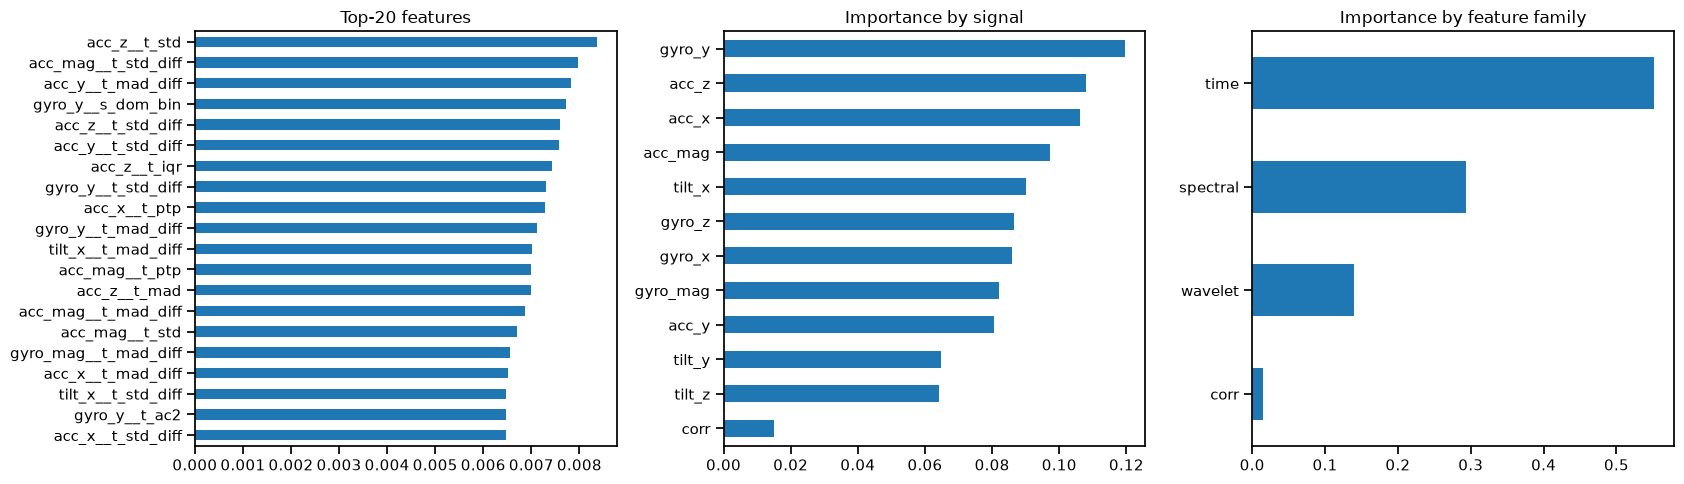

In [10]:
# 9. Feature importance (aggregated by signal and by feature type)
et_imp = get_model_makers()["ExtraTrees"]().fit(F_dev.values.astype(np.float32), y_dev)
imp = pd.Series(et_imp.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
by_signal = imp.groupby(lambda c: c.split("__")[0]).sum().sort_values(ascending=False)
by_type = imp.groupby(lambda c: "corr" if c.startswith("corr__") else c.split("__")[1].split("_")[0]
                      ).sum().rename({"t": "time", "s": "spectral", "w": "wavelet"})

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
imp.head(20)[::-1].plot.barh(ax=ax[0], title="Top-20 features")
by_signal[::-1].plot.barh(ax=ax[1], title="Importance by signal")
by_type.sort_values().plot.barh(ax=ax[2], title="Importance by feature family")
plt.tight_layout()
plt.show()

HELD-OUT TEST (unseen sessions):
              acc  balanced_acc  macro_F1
model                                    
ExtraTrees  0.545         0.506     0.375
Blend       0.545         0.506     0.375

Per-class report on the held-out test (ExtraTrees):
                        precision    recall  f1-score   support

                carpet       0.50      1.00      0.67        57
              concrete       0.61      0.25      0.35        56
         fine_concrete       0.97      0.62      0.76        56
            hard_tiles       0.74      0.74      0.74        57
hard_tiles_large_space       0.03      0.20      0.06         5
              soft_pvc       0.61      0.54      0.57        57
            soft_tiles       0.11      0.67      0.18         3
                 tiled       0.25      0.02      0.04        45

             micro avg       0.55      0.54      0.55       336
             macro avg       0.48      0.51      0.42       336
          weighted avg       0.61      0

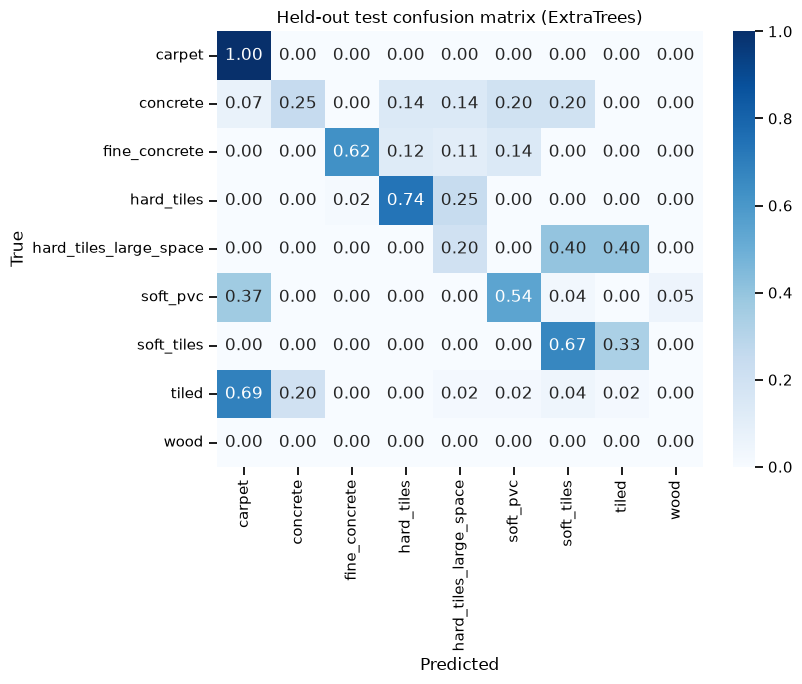


Accuracy per held-out session (a few sessions = noisy; trust the repeated CV more):
                        surface   n    acc
session                                   
0                    hard_tiles  57  0.737
7                      concrete  56  0.250
11                fine_concrete  56  0.625
15                       carpet  57  1.000
16                        tiled  45  0.022
24       hard_tiles_large_space   5  0.200
29                     soft_pvc  57  0.544
30                   soft_tiles   3  0.667


In [11]:
# 10. FINAL TEST: fit on all dev sessions, score once on the untouched held-out sessions
makers = get_model_makers()
Fd, Ft = F_dev.values.astype(np.float32), F_te.values.astype(np.float32)
test_probs = {}
for name, mk in makers.items():
    m = mk().fit(Fd, y_dev)
    test_probs[name] = expand_proba(m.predict_proba(Ft), m.classes_, N_CLASSES)
test_probs["Blend"] = np.mean([test_probs[n] for n in makers], axis=0)

rows = []
for name, p in test_probs.items():
    pr = p.argmax(1)
    rows.append({"model": name, "acc": accuracy_score(y_te, pr),
                 "balanced_acc": balanced_accuracy_score(y_te, pr),
                 "macro_F1": f1_score(y_te, pr, average="macro")})
print("HELD-OUT TEST (unseen sessions):")
print(pd.DataFrame(rows).set_index("model").round(3).to_string())

final_name = "Blend" if len(makers) > 1 else "ExtraTrees"
pred_te = test_probs[final_name].argmax(1)
present = sorted(set(y_te))
print(f"\nPer-class report on the held-out test ({final_name}):")
print(classification_report(y_te, pred_te, labels=present,
                            target_names=[CLASSES[i] for i in present], zero_division=0))
plot_cm(y_te, pred_te, f"Held-out test confusion matrix ({final_name})")

per_session = (pd.DataFrame({"session": g_te, "surface": le.inverse_transform(y_te),
                             "correct": pred_te == y_te})
               .groupby("session").agg(surface=("surface", "first"), n=("correct", "size"),
                                       acc=("correct", "mean")).round(3))
print("\nAccuracy per held-out session (a few sessions = noisy; trust the repeated CV more):")
print(per_session.to_string())

In [12]:
# 11. Refit on ALL labelled sessions, save, and predict new data
final_models = {}
F_full = F_all.values.astype(np.float32)
for name, mk in get_model_makers().items():
    final_models[name] = mk().fit(F_full, y)

bundle = {"models": final_models, "feature_cols": FEATURE_COLS, "classes": CLASSES}
joblib.dump(bundle, f"{OUT_DIR}/approach_a_bundle.joblib")


def predict_surface(X_new, bundle=bundle):
    """X_new: raw array (N, 10, 128) -> (labels, probabilities)."""
    F = featurize(X_new).values.astype(np.float32)
    probs = np.mean([expand_proba(m.predict_proba(F), m.classes_, len(bundle["classes"]))
                     for m in bundle["models"].values()], axis=0)
    return np.array(bundle["classes"])[probs.argmax(1)], probs


ext_path = f"{DATA_DIR}/X_test.npy"
if os.path.exists(ext_path):
    X_ext = np.load(ext_path)
    labels, probs = predict_surface(X_ext)
    out = pd.DataFrame({"series_id": np.arange(len(labels)), "surface": labels,
                        "confidence": probs.max(1).round(3)})
    out.to_csv(f"{OUT_DIR}/predictions_X_test.csv", index=False)
    print(f"\nPredicted {len(out)} windows from X_test.npy -> {OUT_DIR}/predictions_X_test.csv")
    print(out["surface"].value_counts().to_string())
else:
    print("\n(no X_test.npy found; skipped external prediction)")

print(f"\nSaved model bundle -> {OUT_DIR}/approach_a_bundle.joblib")


Predicted 1705 windows from X_test.npy -> outputs_approach_a/predictions_X_test.csv
surface
soft_pvc                  474
carpet                    465
hard_tiles                326
fine_concrete             141
hard_tiles_large_space    132
concrete                   81
soft_tiles                 44
tiled                      23
wood                       19

Saved model bundle -> outputs_approach_a/approach_a_bundle.joblib
